In [1]:
from lcpy.calculators.bw_int import mpLCAer
import os
from lcpy.hvs.hvs import (store_scenario_results, create_scenario_dataframes, save_scenario_dataframes, create_and_save_dataframes_per_scenario_and_per_category, create_and_save_dataframes_time_series, visualize_dict_lineplots, plot_bar_charts_by_category, visualize_stacked_barchart_time_series_impact, make_characterized_inventory_dfs)
from lcpy.calculators.env_calc import fast_calculator
from lcpy.hvs.map_dicts import create_mapping, create_list_with_unique_activities, store_dictionaries
import numpy as np

The initial configuration remains the same with previous examples

In [2]:
target_dir = "path_of_directory_where_to_store_results"
os.makedirs(target_dir, exist_ok=True)

In [3]:
brightway_configuration_dictionary = {
    "path_to_brightway_project": "path_to_folder_containing_the_bw_environment_and_packages_installed_there",
    "bw_project": "bw_project_name",
    "bw_database": "bw_project_database_name",
    "bw_biosphere": "bw_project_biosphere_database_name",
    "bw_ecoinvent": "ecoinvent_database_used_name"
}

In [4]:
methods_list = [
('TRACI v2.1', 'acidification', 'acidification potential (AP)'),
('TRACI v2.1', 'climate change', 'global warming potential (GWP100)'),
('TRACI v2.1', 'ecotoxicity: freshwater', 'ecotoxicity: freshwater'),
('TRACI v2.1', 'eutrophication', 'eutrophication potential'),
('TRACI v2.1', 'human toxicity: carcinogenic', 'human toxicity: carcinogenic'),
('TRACI v2.1', 'human toxicity: non-carcinogenic', 'human toxicity: non-carcinogenic'),
('TRACI v2.1', 'ozone depletion', 'ozone depletion potential (ODP)'),
('TRACI v2.1', 'particulate matter formation', 'particulate matter formation potential (PMFP)'),
('TRACI v2.1', 'photochemical oxidant formation', 'maximum incremental reactivity (MIR)'),
]

method_units_list = ['kg SO2-Eq',
 'kg CO2-Eq',
 'CTUe',
 'kg N-Eq',
 'CTUh',
 'CTUh',
 'kg CFC-11-Eq',
 'kg PM2.5-Eq',
 'kg O3-Eq',
]

In [5]:
methods_gp = methods_list[:]
impact_categories_names = ['AP', 'GWP100', 'ECFW', 'EP', 'HTC', 'HTNC', 'ODP', 'PMFP', 'MIR']

We now need to set the parameters for the dynamic analysis. We define the number of scenarios to run. We set this to one for simplicity in this example.
We define the timeframe and time_step of the analysis. These regard the operation of the system. We consider an operation of 10 years and a time_step for the analysis of 1 year. We finally define the number of years needed for the construction of the infrastructure needed for the system (if included in the analysis) and how many
sub-processes we are to consider for the construction of the infrastructure. The final time horizon of our inventory becomes timeframe + construction_years.

In [6]:
scenarios = 1
timeframe = 10 #operational lifetime after construction
time_step = 1
construction_years = 1
number_of_infrastructure_processes = 1

We next define the parametric model. We include some evolution in the installed capacity per technology type to demonstrate the semi-dynamic method. We assume that
the BWR capacity is going to increase, the PWR capacity is going to decrease, and natural gas capcity is going to remain constant, and the RES capacity is going to
increase.

We alter slightly the example, considering a main process that consists of three sub-processes: Electricity consumption, chemical consumption, and waste treatment. The construction of a generic plant is also considered.

The considered inventory is:
Generic plant.
Electricity consumption: 500 kWh
Chemical 1 consumption: 40 kg
Chemical 2 consumption: 80 kg
Produced product: 50 kg (functional unit)
Material landfill: (80 + 40) - 50 kg

And we consider that these amounts change over time.

We first define the parameters for the operation

In [7]:
bwr_growth = (1. + 0.02)**(timeframe // time_step)
pwr_growth = (1. - 0.01)**(timeframe // time_step)
hydro_growth = (1. + 0.01)**(timeframe // time_step)
dge_growth = (1. + 0.04)**(timeframe // time_step)
wind_growth = (1. + 0.02)**(timeframe // time_step)

In [8]:
BWR_capacity = np.tile(1500.*bwr_growth, (scenarios, 1))
PWR_capacity = np.tile(800.*pwr_growth, (scenarios, 1))

NG_ccpp_capacity = np.full((scenarios, timeframe // time_step), 400.)
NG_cogen_conv_capacity = NG_ccpp_capacity * np.random.uniform(low=0.1, high=0.1, size=(scenarios, timeframe // time_step))
NG_convpp_capacity = np.full((scenarios, timeframe // time_step), 1100.)
NG_cogen_cc_capacity = np.full((scenarios, timeframe // time_step), 230.)

Hydro_pumped_capacity = np.tile(420.*hydro_growth, (scenarios, 1))
DGE_capacity = np.tile(85.*dge_growth, (scenarios, 1))
Wind_1_3_capacity = np.tile(980.*wind_growth, (scenarios, 1))

In [9]:
total_capacity = BWR_capacity + PWR_capacity + NG_ccpp_capacity + NG_cogen_conv_capacity + NG_convpp_capacity + NG_cogen_cc_capacity + Hydro_pumped_capacity + DGE_capacity + Wind_1_3_capacity

In [10]:
bwr_share = BWR_capacity / total_capacity
pwr_share = PWR_capacity / total_capacity
ng_ccpp_share = NG_ccpp_capacity / total_capacity
ng_cogen_share = NG_cogen_conv_capacity / total_capacity
ng_convpp_share = NG_convpp_capacity / total_capacity
ng_cogen_cc_share = NG_cogen_cc_capacity / total_capacity
hydro_share = Hydro_pumped_capacity / total_capacity
dge_share = DGE_capacity / total_capacity
wind_share = Wind_1_3_capacity / total_capacity

In [11]:
butanol_consumption = np.full((scenarios, timeframe // time_step), 80.)
other_chemical_consumption = np.ones((scenarios, timeframe // time_step))

In [12]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        other_chemical_consumption[i, j] = 40. + (40. * 0.01*j)

In [13]:
total_fu = np.full((scenarios, timeframe // time_step), 1.)

In [14]:
for i in range(scenarios):
    for j in range(timeframe // time_step):
        total_fu[i, j] = 50. + (30. * 0.05*j)

In [15]:
total_fu = total_fu

In [16]:
waste_material = butanol_consumption + other_chemical_consumption - total_fu

In [17]:
total_fu = [total_fu]

And now we define the parameters for the construction (note the difference in the numpy array dimensions)

In [18]:
building = np.full((scenarios, construction_years),1.)

We now construct the dictionaries and lists to model the sub-processes and the main process

In [19]:
keys_infrastructure = {
    'Building' : 'bw_key_pointing_to_relevant_process'
}

infrastructure_exchanges_amounts = [
    building
]

In [20]:
keys_electricity_consumption = {
'PWR' :  'bw_key_pointing_to_relevant_process',
'BWR' : 'bw_key_pointing_to_relevant_process',
'NG_ccpp' :  'bw_key_pointing_to_relevant_process',
'NG_convpp' : 'bw_key_pointing_to_relevant_process',
'NG_cogen_conv' :  'bw_key_pointing_to_relevant_process',
'NG_cogen_cc' : 'bw_key_pointing_to_relevant_process',
'Hydro' :  'bw_key_pointing_to_relevant_process',
'DGE' : 'bw_key_pointing_to_relevant_process',
'Wind' :  'bw_key_pointing_to_relevant_process',
}

electricity_exchanges_amounts = [
    pwr_share*500,
    bwr_share*500,
    ng_ccpp_share*500,
    ng_convpp_share*500,
    ng_cogen_share*500,
    ng_cogen_cc_share*500,
    hydro_share*500,
    dge_share*500,
    wind_share*500,
]

keys_chemical_consumption = {
    'butanol': 'bw_key_pointing_to_relevant_process',
    'other chemical': 'bw_key_pointing_to_relevant_process'
}

chemicals_exchanges_amounts = [
    butanol_consumption,
    other_chemical_consumption,
]

keys_waste = {
    'Solid waste': 'bw_key_pointing_to_relevant_process'
}

waste_exchanges_amounts = [
    -waste_material
]

In [21]:
keys_main_process = {
'Infrastructure': '',
'Electricity consumption': '',
'Chemical consumption' :  '',
'Waste handling' :  '',
}

mp_exchanges_amounts = [
1./(50*50000*1000) * np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
]

Once we have set up the dictionaries and lists that model the sub-processes and the main process, we proceed until the calculation of the unit_impacts and unit_inventory
for each sub-sub-process and before start the scaling

In [22]:
key_list_sub_processes = [keys_infrastructure, keys_electricity_consumption, keys_chemical_consumption, keys_waste]

exchanges_list_sub_processes = [infrastructure_exchanges_amounts, electricity_exchanges_amounts, chemicals_exchanges_amounts,
                                      waste_exchanges_amounts]

In [23]:
mapping_names = create_mapping(keys_main_process, key_list_sub_processes)

In [24]:
unique_activities = create_list_with_unique_activities(key_list_sub_processes)

In [25]:
mapping_exchanges = create_mapping(keys_main_process, exchanges_list_sub_processes)

In [26]:
my_lca = mpLCAer(6, methods_gp, brightway_configuration_dictionary)

In [27]:
my_lca.import_isolated_environment()

In [28]:
my_lca.lca_calculations(mapping_names)

In [29]:
my_calculator = fast_calculator()

Now for each sub-process, we scale the unit impacts of each sub-sub-process included with the exchange amounts needed. We do this for each scenario and time step.
The unit impact results for each sub-process are stored in the impact attribute and the contributions per sub-sub-process are stroed in the impact_per_process attribute


In [30]:
my_calculator.calculation_static_lcia(mapping_exchanges, my_lca.unit_impacts)

And now we directly scale the unit impacts of the sub-processes with the exchange amounts needed for the main process

In [31]:
my_calculator.impact_calculation_total(mp_exchanges_amounts, my_calculator.impact, number_of_infrastructure_processes, construction_years, "Main process")

We have above calculated the impact per process. However, we have not been concerned with the environmental flows and how much impact these cause.
We can calculate these results and put them in a dataframe using the below functions, which are better explained in the fully-dynamic LCA example.

In [32]:
my_lca.derive_technosphere_and_biosphere_dictionaries(mapping_names, "Main process")

All biosphere dictionaries are the same
All technosphere dictionaries are the same


In [33]:
store_dictionaries(my_lca.biosphere_dict['Main process'], target_dir, 'Biosphere_Flows.xlsx')

In [34]:
store_dictionaries(my_lca.technosphere_dict['Main process'], target_dir, 'Technosphere_Flows.xlsx')

In [35]:
my_calculator.sum_inventory_per_sub_sub_process(my_lca.unit_inventory)

In [36]:
my_calculator.sum_characterized_inventory_per_sub_sub_process(my_lca.unit_char_inventory)

In [37]:
my_calculator.emissions_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_inventories)

In [38]:
my_calculator.characterized_inventory_calculation_in_time(mapping_exchanges, my_calculator.summed_unit_characterized_inventories)

In [39]:
my_calculator.emissions_calculation_in_time_total(mp_exchanges_amounts, my_calculator.inventory, number_of_infrastructure_processes, construction_years, "Main process" )

In [40]:
my_calculator.characterized_inventory_calculation_in_time_total(mp_exchanges_amounts, my_calculator.characterized_inventory, number_of_infrastructure_processes, construction_years, "Main process")

In [41]:
dictionary_with_dfs_per_environmental_flow_mp = make_characterized_inventory_dfs(my_calculator.total_char_inventory['Main process'],
                                        impact_categories_names, my_lca.biosphere_dict['Main process'],
                                        0)

In [42]:
dictionary_with_dfs_per_environmental_flow_elec_cons = make_characterized_inventory_dfs(my_calculator.characterized_inventory['Electricity consumption'],
                                        impact_categories_names, my_lca.biosphere_dict['Main process'],
                                        0)

We have now calculated the impact results for the main process at each scenario and time step. These are stored in dictionary attributes of the my_calculator instance.
Separate dictionary attributes are stored for the total impact and the the contribution of each sub-process. Below we present functions that exploit the calculated
results to present the LCA results.

The below function sums the impact caused in each time-step for each impact category investigated and per scenario. The result is stored in a dictionary attribute of
my_calculator

In [43]:
my_calculator.calculate_total_impact_per_category_and_scenario('Main process')

The modelling performed in the dictionaries and lists is for the absolute impact caused. The functional unit (amount of product produced in each time step and scenario) is also calculated in the total_fu variable.

Below we calculate the total amount of product produced in each scenario.

In [44]:
my_calculator.calculate_total_fu_per_scenario(total_fu, 'Main process')

And now the impact of the main process per functional unit produced.

In [45]:
my_calculator.per_fu_per_category_per_scenario('Main process')

The below function calculates the in-time evolution of the impact caused

In [46]:
my_calculator.calculation_of_the_in_time_impact_evolution_absolute('Main process')

And the below calculates the in-time evolution of the impact caused per functional unit

In [47]:
my_calculator.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual(construction_years, 'Main process')

The below functions can be used to create dataframes with the results calculated above to store and visualize them. They use dictionary attributes of my_calculator that were calculated above.

First we define some names for the scenarios.

Then we create dictionaries holding dataframes with the results at each time_step. Below we create dictionaries for the absolute impact caused, cumulative impact per functional unit in time, impact caused dduring infrastructure and operation, and cumulative absolute impact.

In [48]:
scenario_names = [str(i) for i in range(scenarios)]

In [49]:
scenario_dict_total_impact = create_scenario_dataframes(my_calculator.total_impact['Main process'], impact_categories_names, scenario_names)

In [50]:
scenario_dict_cum_impact_per_fu = create_scenario_dataframes(my_calculator.cum_impact_in_time_per_fu['Main process'], impact_categories_names, scenario_names)

In [51]:
scenario_dict_total_impact_infr = create_scenario_dataframes(my_calculator.total_impact_infr['Main process'], impact_categories_names, scenario_names)

In [52]:
scenario_dict_total_impact_op = create_scenario_dataframes(my_calculator.total_impact_op['Main process'], impact_categories_names, scenario_names)

In [53]:
scenario_dict_cum_impact = create_scenario_dataframes(my_calculator.cum_impact_in_time['Main process'], impact_categories_names, scenario_names)

We continue with creating and saving dataframes with the results.

In [54]:
save_scenario_dataframes(scenario_dict_total_impact, list(scenario_dict_total_impact.keys()), target_dir, 'total_impact', infr_op='op')
save_scenario_dataframes(scenario_dict_cum_impact_per_fu, list(scenario_dict_cum_impact_per_fu.keys()), target_dir, 'cum_impact_per_fu', infr_op='op')
save_scenario_dataframes(scenario_dict_total_impact_infr, list(scenario_dict_total_impact_infr.keys()), target_dir, 'inf_impact', infr_op='infr')
save_scenario_dataframes(scenario_dict_total_impact_op, list(scenario_dict_total_impact_op.keys()), target_dir, 'op_impact', infr_op='op')
save_scenario_dataframes(scenario_dict_cum_impact, list(scenario_dict_cum_impact.keys()), target_dir, 'cum_impact', infr_op='op')

DataFrames saved in: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\impact_total_impact__op.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\impact_cum_impact_per_fu__op.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\impact_inf_impact__infr.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\impact_op_impact__op.xlsx
DataFrames saved in: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\impact_cum_impact__op.xlsx


Below we create and save dataframes with the results

In [55]:
df_impact_per_category_and_scenario= create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_category_and_scenario['Main process'], impact_categories_names, os.path.join(target_dir, 'impact_per_category_per_scenario.xlsx'))

Dataframes not save, set save to True to save them


In [56]:
df_impact_per_fu_category_and_scenario = create_and_save_dataframes_per_scenario_and_per_category(my_calculator.total_impact_per_fu_per_category_per_scenario['Main process'], impact_categories_names, os.path.join(target_dir, 'impact_per_fu_category_per_scenario.xlsx'))

Dataframes not save, set save to True to save them


In [57]:
dataframes_total_impact = create_and_save_dataframes_time_series(my_calculator.total_impact['Main process'], impact_categories_names, scenario_names, excel_file_name= os.path.join(target_dir, 'impacts_time_series.xlsx'))

Dataframes not save, set save to True to save them


In [58]:
dataframes_cum_impact = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time['Main process'], impact_categories_names, scenario_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_time_series.xlsx'))

Dataframes not save, set save to True to save them


In [59]:
dataframes_cum_impact_per_fu = create_and_save_dataframes_time_series(my_calculator.cum_impact_in_time_per_fu['Main process'], impact_categories_names, scenario_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_per_fu_time_series.xlsx'))

Dataframes not save, set save to True to save them


We make some saves

In [60]:
store_scenario_results(df_impact_per_fu_category_and_scenario, target_dir, method_units_list, (5,3), 300, 'Main process')

And we start visualizing our dynamic results, while storing them in dictionaries as well. The visuals are stored in the specified directory.

In [61]:
len(dataframes_cum_impact)

9

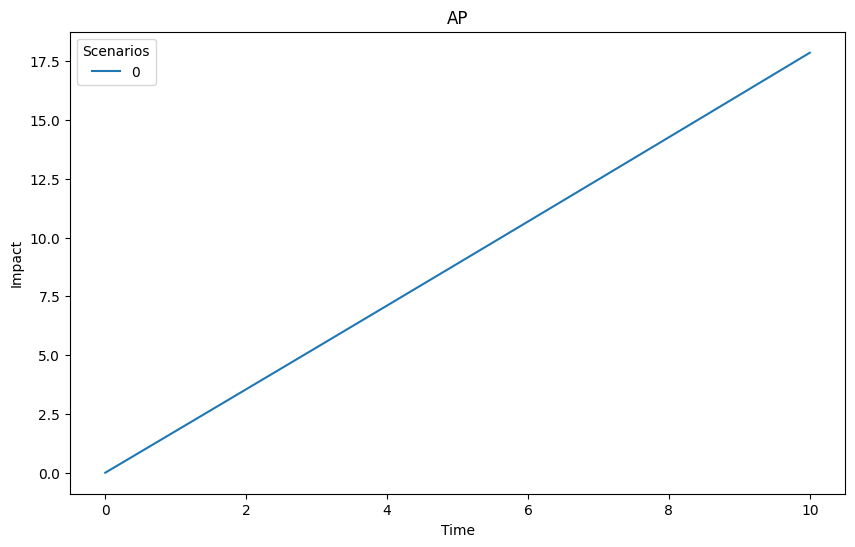

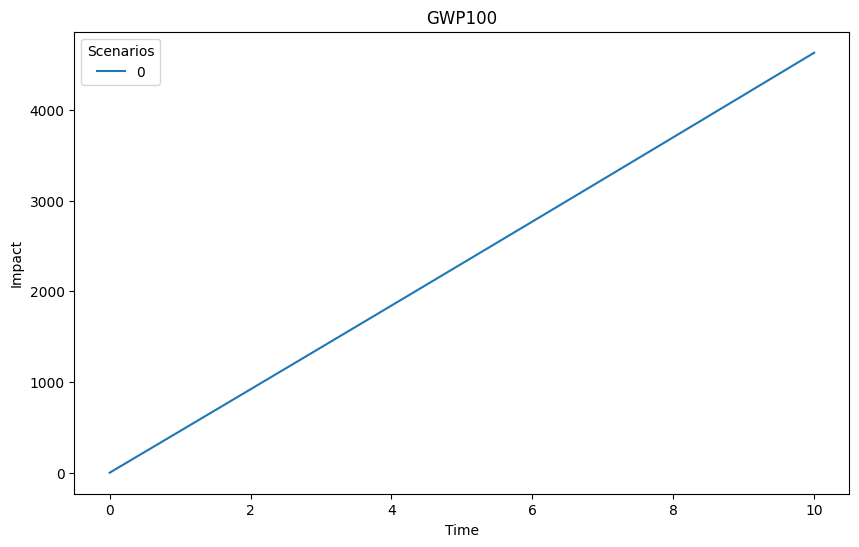

In [62]:
dict_cum_impact_per_category = visualize_dict_lineplots(dataframes_cum_impact, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['0']) # Set which impact categories and scenarios to plot in the list arguments

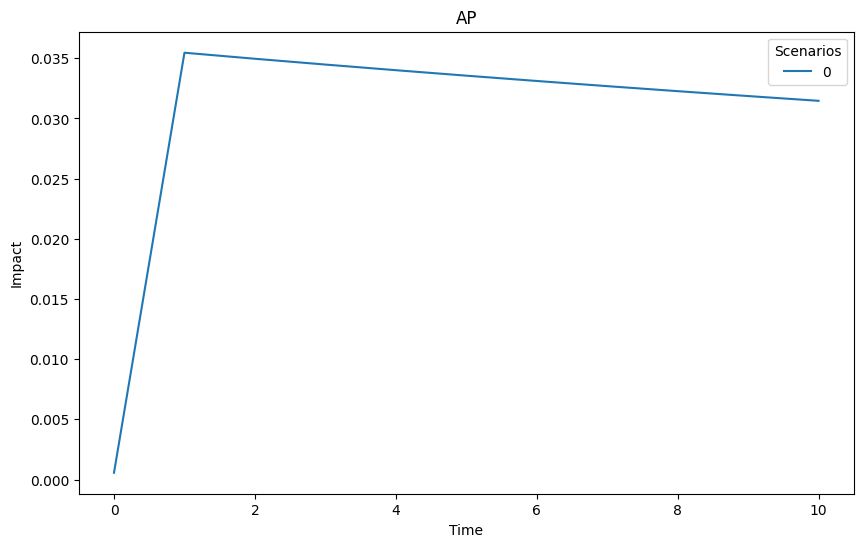

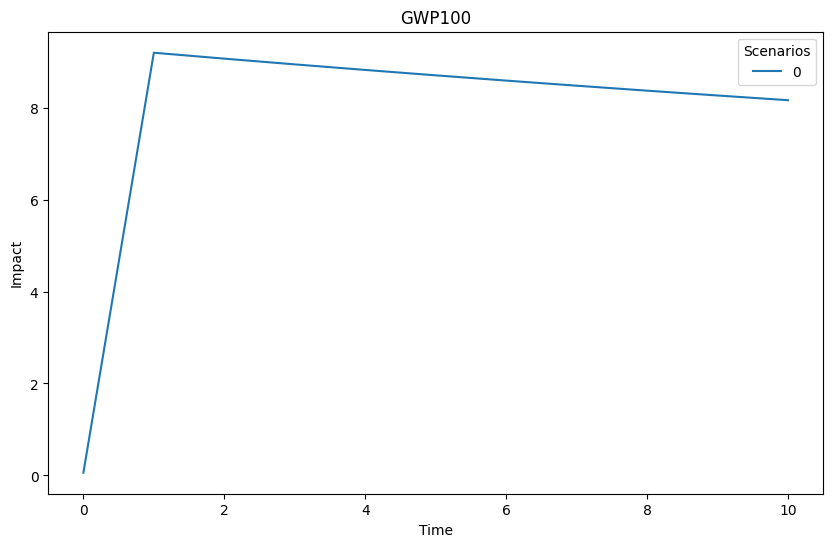

In [63]:
dict_cum_impact_per_fu_per_category = visualize_dict_lineplots(dataframes_cum_impact_per_fu, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['0']) # Set which impact categories and scenarios to plot in the list arguments

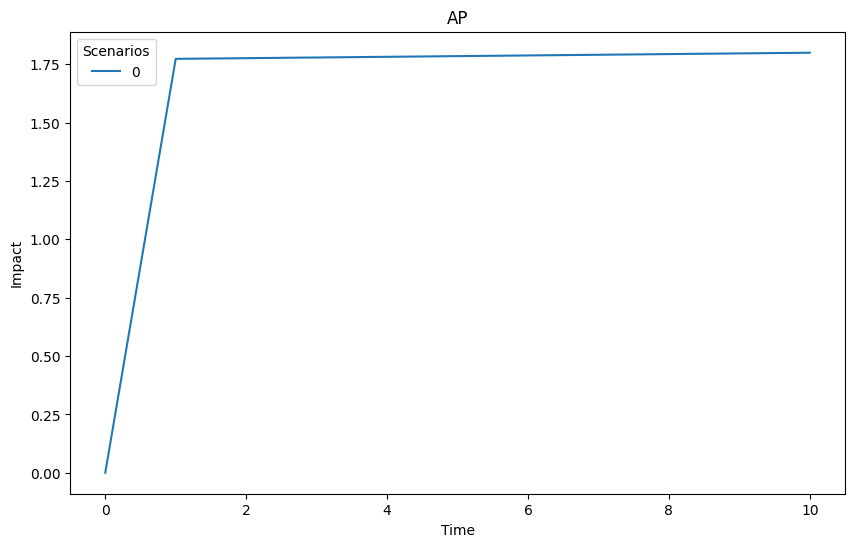

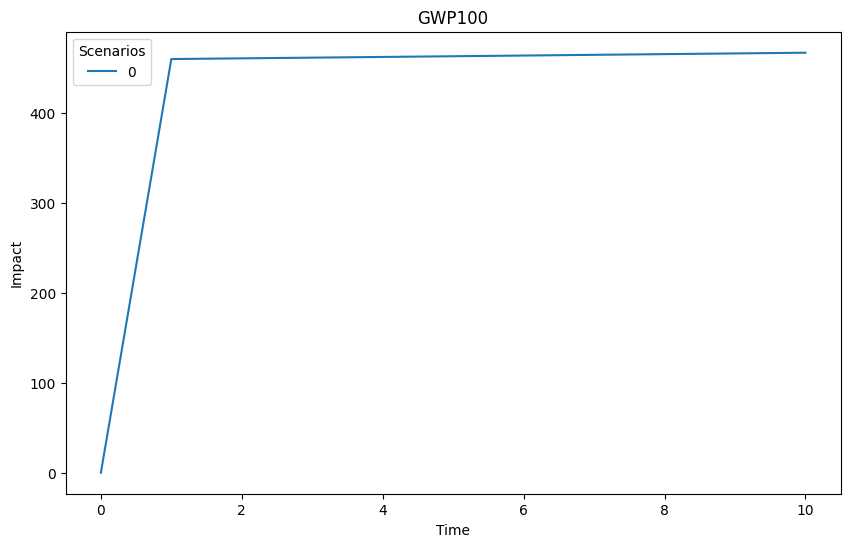

In [64]:
dict_impact_per_category = visualize_dict_lineplots(dataframes_total_impact, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['0']) # Set which impact categories and scenarios to plot in the list arguments

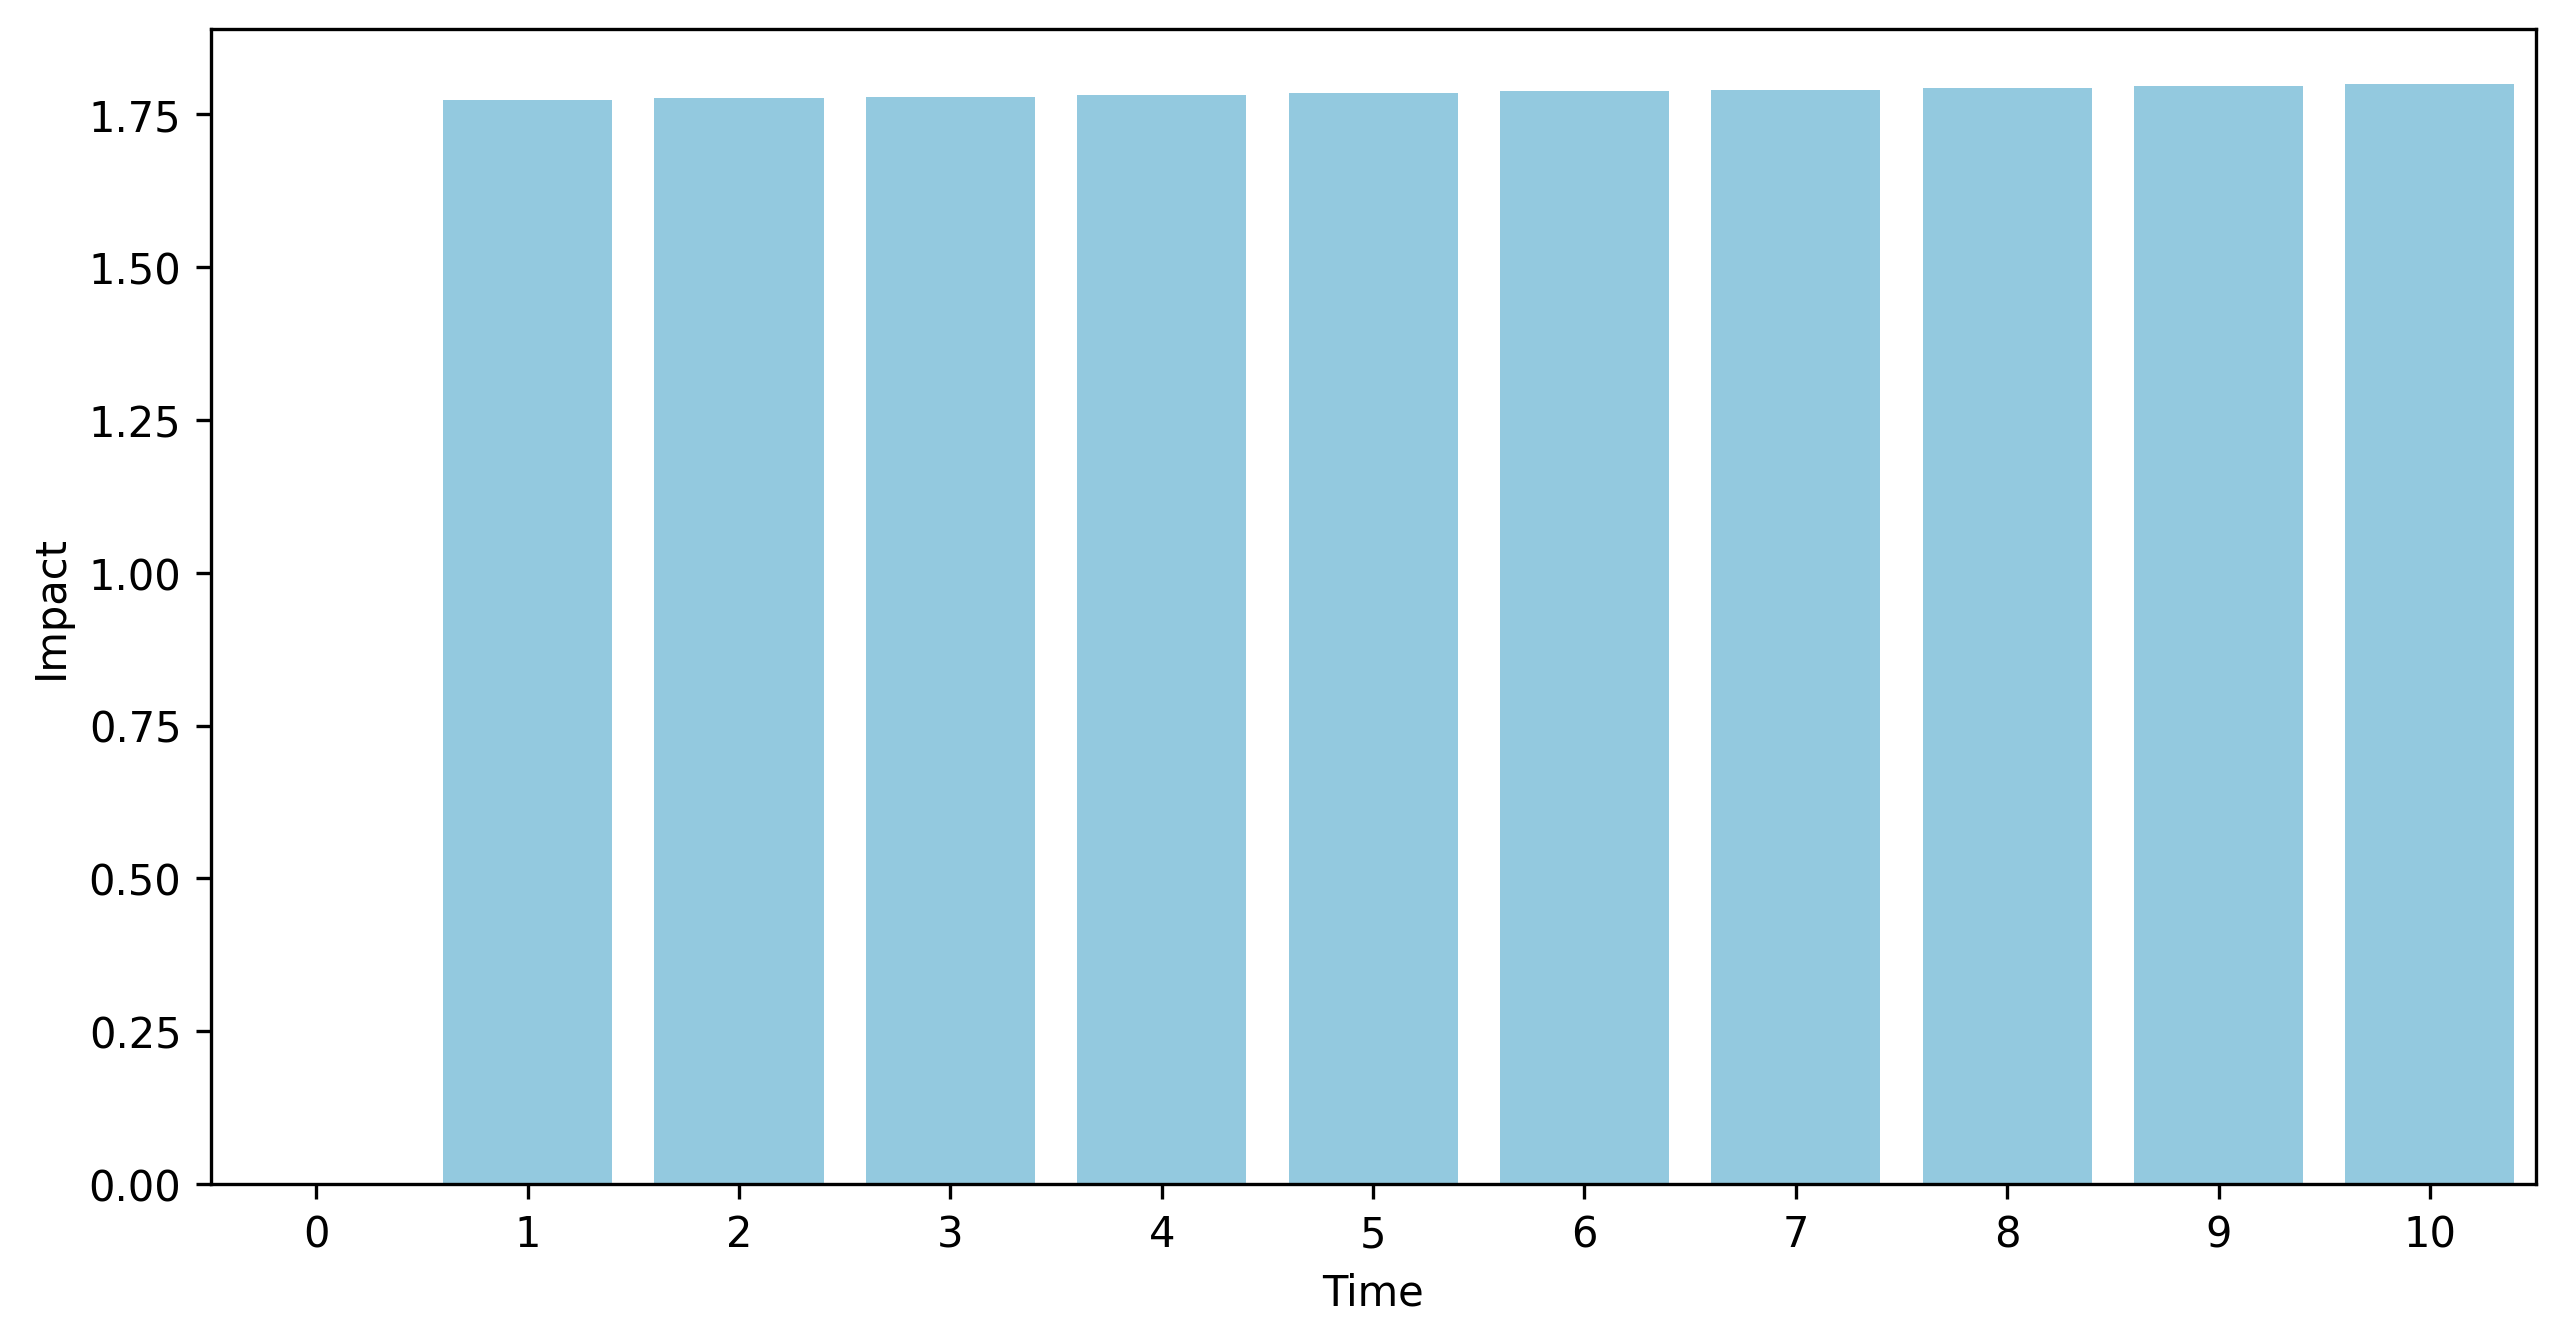

Plot saved: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\0_barplot_AP__.png


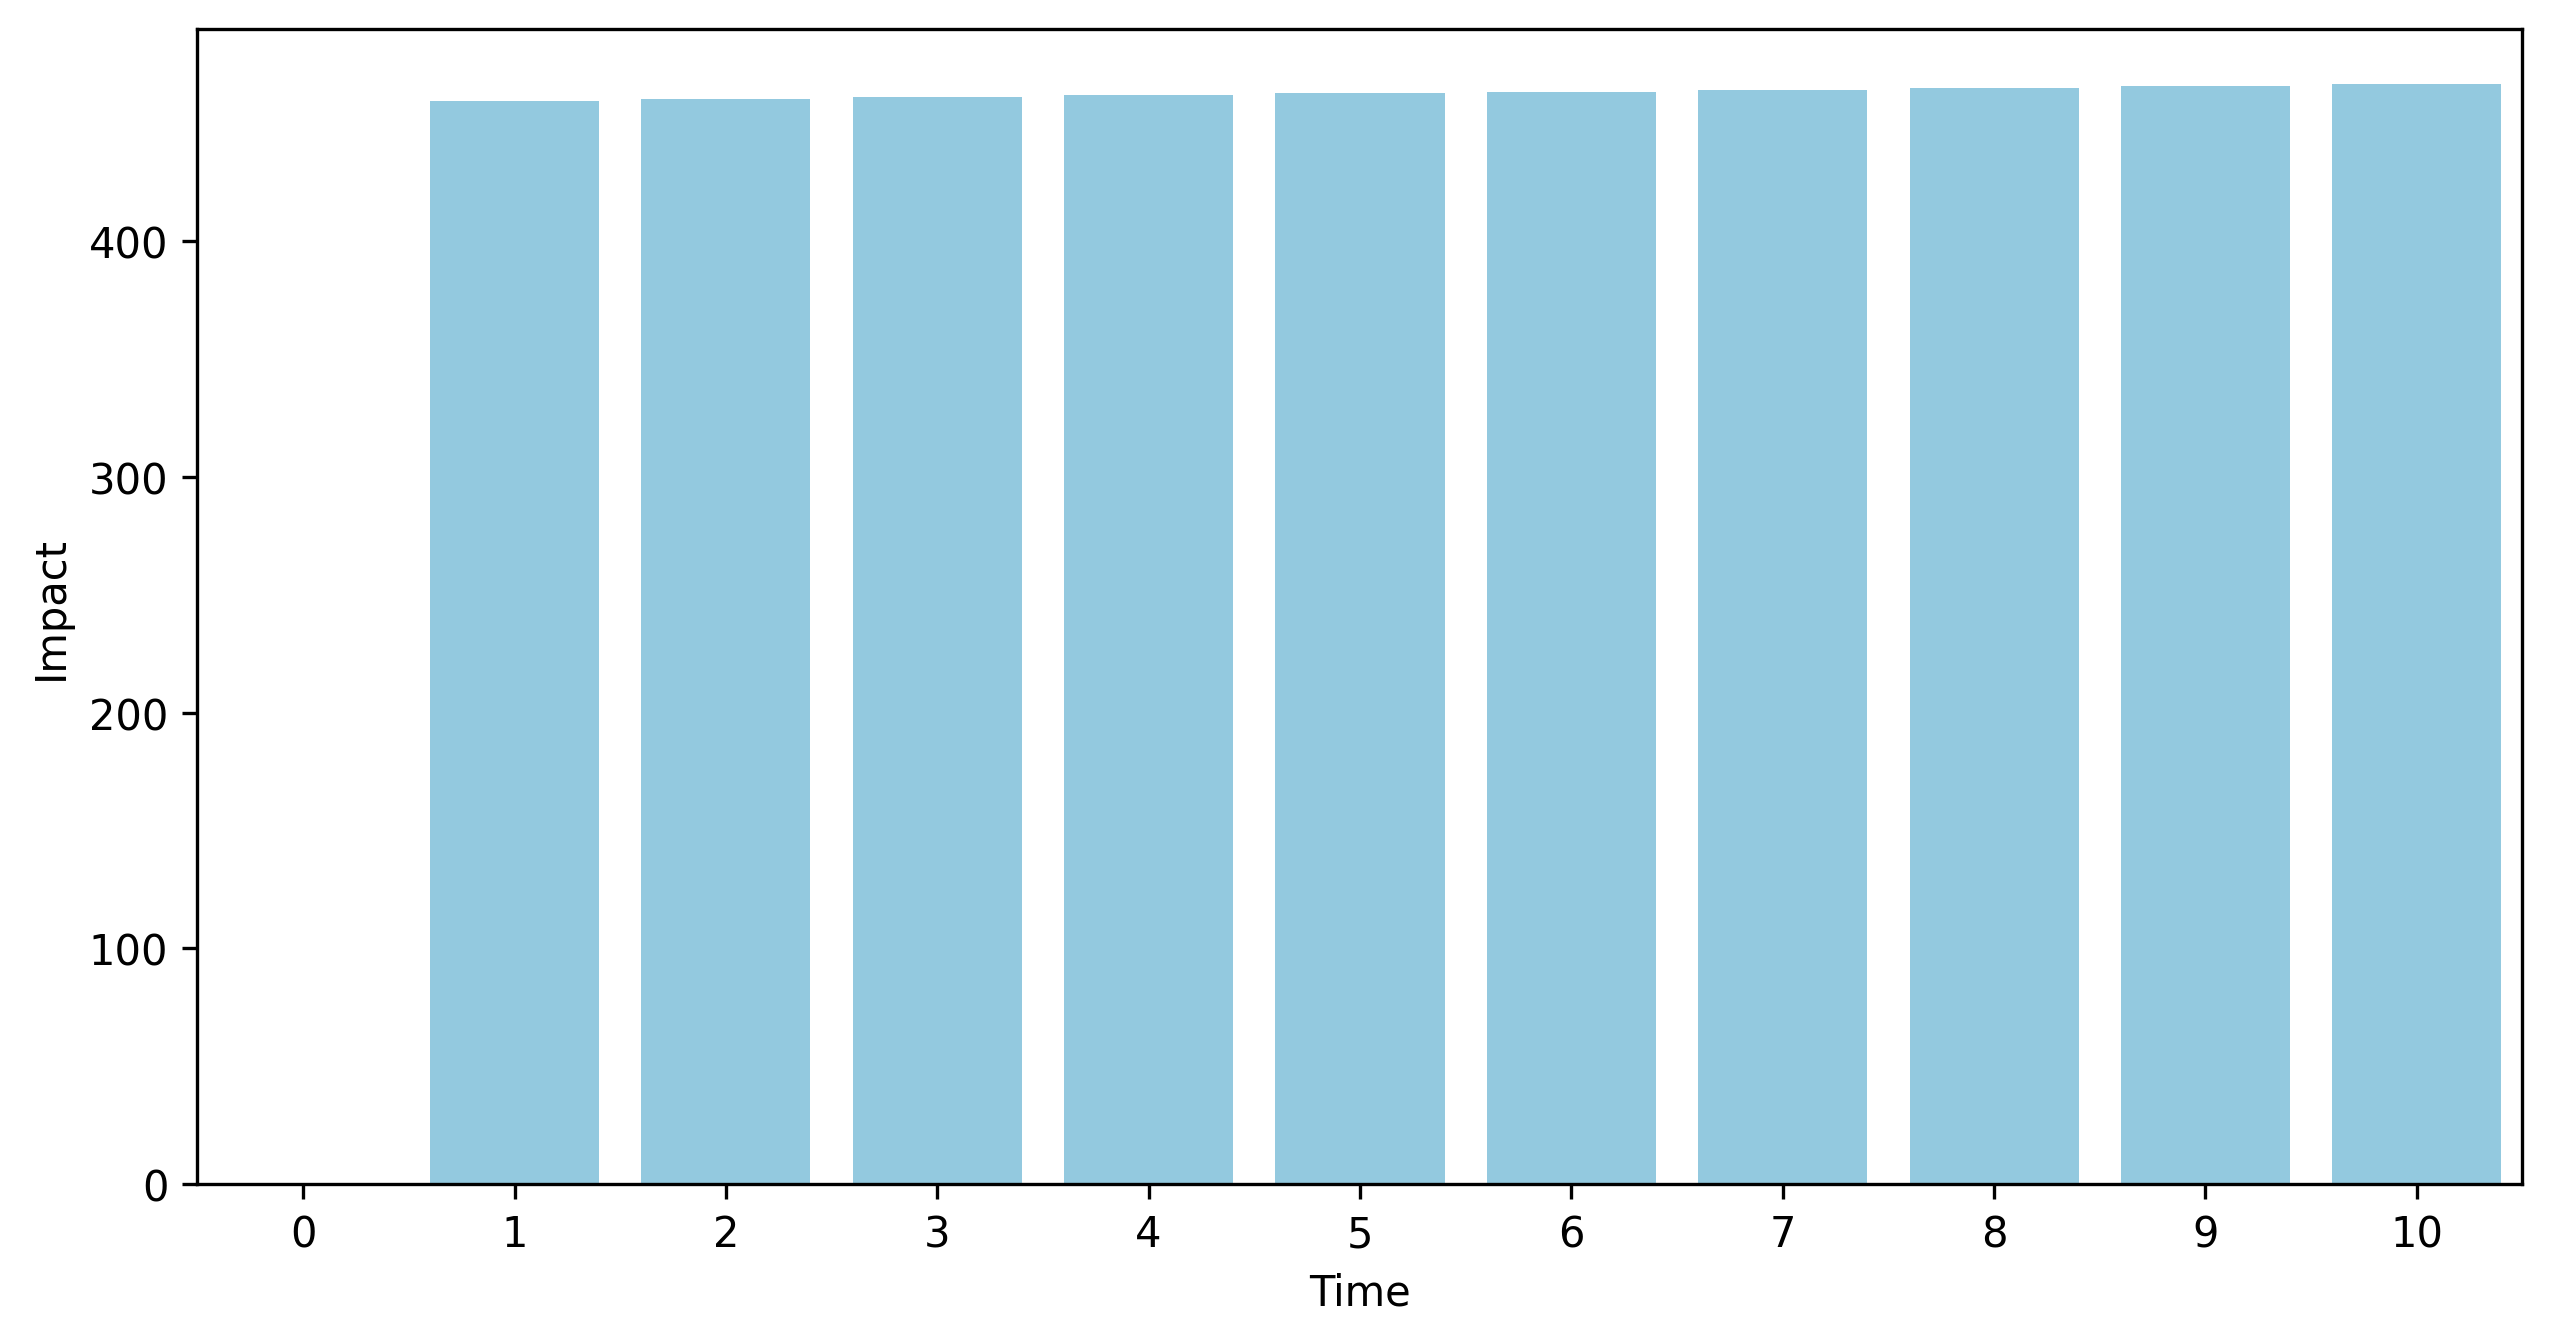

Plot saved: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\0_barplot_GWP100__.png


In [65]:
# All dicitonaries created by create_scenario_dataframes can be plotted
plot_bar_charts_by_category(scenario_dict_total_impact, scenarios_to_plot= ['0'],impacts_to_plot = ['AP', 'GWP100'], target_dir = target_dir)

In [66]:
visualize_stacked_barchart_time_series_impact(my_calculator.total_impact_contributions['Main process'], 0,  impact_categories_names, mapping_names, target_dir, name = "main process")

# The main process as a sub-process

The infrastructural and operational sub-processes of the previous (externally calculated) process need to be included separately in the new main process,
because we need to respect the sequence infrastructural sub-processes - operational sub-processes when modelling these in dictionaries.

As in the previous examples, we first define the new sub-processes and then we will append the externally calculated sub-process (in this case the chemical production modelled above).

In [67]:
number_of_infrastructure_processes_2 = 2
construction_years_2 = 1

In [68]:
keys_chemical_production_infrastructure = {
'Chemical production infrastructure': ''
}
exchange_list_chemical_production_infrastructure = [
np.full((scenarios, construction_years_2),1.)
]

In [69]:
key_chemical_production_operation = {
'Chemical production': ''
}
exchange_list_chemical_production_operation = [
np.full((scenarios, timeframe//time_step),1.)
]

In [70]:
keys_infrastructure_new_main_process = {
    'Building' : 'bw_key_pointing_to_relevant_process'
}

infrastructure2_exchanges_amounts_2 = [np.full((scenarios, construction_years_2),1.)]

In [71]:
keys_other_sub_process = {
'butanol': 'bw_key_pointing_to_relevant_process',
'other chemical': 'bw_key_pointing_to_relevant_process'
}
# We consider the same amounts with before just for demonstration purposes
other_sub_process_exchanges_amounts =[
    butanol_consumption,
    other_chemical_consumption,
]

In [72]:
keys_total_new_main_process = {
'Infrastructure (2)': '',
'Other sub-process' :  ''
}

total_exchanges_new_main_process = [
1./(50*50000*1000) * np.full((scenarios, timeframe // time_step),1.),
np.full((scenarios, timeframe // time_step),1.),
]

In [73]:
key_list_production_new_main_process = [keys_infrastructure_new_main_process, keys_other_sub_process]
exchanges_list_production_new_main_process = [infrastructure2_exchanges_amounts_2, other_sub_process_exchanges_amounts]

We continue as usual until we calculate the unit impact and inventory per sub-sub-process ncluded in each sub-process

In [74]:
mapping_new_main_process = create_mapping(keys_total_new_main_process, key_list_production_new_main_process)

In [75]:
unique_activities_new_main_process = create_list_with_unique_activities(key_list_production_new_main_process)

In [76]:
mapping_exch_new_main_process = create_mapping(keys_total_new_main_process, exchanges_list_production_new_main_process)

In [77]:
my_lca_new_main_process = mpLCAer(6, methods_gp, brightway_configuration_dictionary)

In [78]:
my_lca_new_main_process.import_isolated_environment()

In [79]:
my_lca_new_main_process.lca_calculations(mapping_new_main_process)

We then continue to scale the unit impacts of each sub-sub-process with the exchange amounts required in each sub-process

In [80]:
my_calculator_new_main_process = fast_calculator()

In [81]:
my_calculator_new_main_process.calculation_static_lcia(mapping_exch_new_main_process, my_lca_new_main_process.unit_impacts)

At this point we need to append the information for the externally calculated sub-processes. We need to include infrastructural sub-processes at the start of the dictionaries and lists and operational sub-process at the end. We use OrderedDict for this.

Next, we make nine appends as explained in the below cells.

In [82]:
from collections import OrderedDict

my_calculator_new_main_process.impact = OrderedDict(my_calculator_new_main_process.impact)
my_calculator_new_main_process.impact_per_process = OrderedDict(my_calculator_new_main_process.impact_per_process)

First we append the impact dictionary (holding the unit impacts of the sub-processes) with the unit_impact of the infrastructural sub-processes that have been pre-calculated

In [83]:
my_calculator_new_main_process.impact['Chemical production infrastructure'] = my_calculator.total_impact_infr['Main process']
my_calculator_new_main_process.impact.move_to_end('Chemical production infrastructure', last=False)

Second we append the impact dictionary (holding the unit impacts of the sub-processes) with the unit_impact of the operational sub-processes that have been pre-calculated

In [84]:
my_calculator_new_main_process.impact['Chemical production'] = my_calculator.total_impact_op['Main process']

Third, we append the impact_per_process dictionary (holding the unit impacts of the sub-processes per sub-sub-process) with the unit_impact of the infrastructural sub-processes that have been pre-calculated and with the unit_impact of the operational sub-processes that have been pre-calculated


In [85]:
my_calculator_new_main_process.impact_per_process['Chemical production infrastructure'] = my_calculator.total_impact_infr['Main process'].reshape(1, len(impact_categories_names), scenarios, construction_years)
my_calculator_new_main_process.impact_per_process.move_to_end('Chemical production infrastructure', last=False)

my_calculator_new_main_process.impact_per_process['Chemical production'] = my_calculator.total_impact_op['Main process']

Forth we append the mapping dictionary:

In [86]:
mapping_new_main_process = OrderedDict(mapping_new_main_process)
mapping_new_main_process['Chemical production infrastructure'] = ['']
mapping_new_main_process.move_to_end('Chemical production infrastructure', last=False)

mapping_new_main_process['Chemical production'] = ['']

Fifth, we append the mapping_exchanges_dictionary:

In [87]:
mapping_exch_new_main_process = OrderedDict(mapping_exch_new_main_process)
mapping_exch_new_main_process['Chemical production infrastructure'] = [np.full((scenarios, construction_years_2),1.)]
mapping_exch_new_main_process.move_to_end('Chemical production infrastructure', last=False)

mapping_exch_new_main_process['Chemical production'] = [np.full((scenarios, timeframe//time_step),1.)]

Sixth, we append the key_list_production_new_main_process list that holds the mapping dicitonaries for each sub-process


In [88]:
key_list_production_new_main_process.insert(0, {'Chemical Production': ''})
key_list_production_new_main_process.append({'Chemical Production': ''})

Seventh we append the exchanges_list_production_new_main_process list that holds the exchanges amounts in lists for each each sub-process. We do not need to do that in principle, since we have already appended the required in the mapping_exch_new_main_process dictionary, but we do it for consistency and for better inspection

In [89]:
exchanges_list_production_new_main_process.insert(0, [np.full((scenarios, construction_years_2),1.)])
exchanges_list_production_new_main_process.append([np.full((scenarios, timeframe//time_step),1.)])

Eigth, we append the keys dictionary of the new main process

In [90]:
keys_total_new_main_process = OrderedDict(keys_total_new_main_process)
keys_total_new_main_process['Chemical production infrastructure'] = ''
keys_total_new_main_process.move_to_end('Chemical production infrastructure', last=False)

keys_total_new_main_process['Chemical production'] = ''

Ninth, we append the exchanges list of the new main process

In [91]:
total_exchanges_new_main_process.insert(0, 1./(50*50000*1000) * np.full((scenarios, timeframe//time_step),1.))
total_exchanges_new_main_process.append(1. * np.full((scenarios, timeframe//time_step),1.))

The rest of the analysis uses the exact same functions as the original example (beginning of this notebook). A functional unit should be set also (if desired and the modelling should be made with caution to represent the problem to be solved.

In [92]:
my_calculator_new_main_process.impact_calculation_total(total_exchanges_new_main_process, my_calculator_new_main_process.impact, number_of_infrastructure_processes_2, construction_years, "New main process")

In [93]:
my_calculator_new_main_process.calculate_total_impact_per_category_and_scenario('New main process')

In [94]:
my_calculator_new_main_process.calculate_total_fu_per_scenario(total_fu, 'New main process')

In [95]:
my_calculator_new_main_process.per_fu_per_category_per_scenario('New main process')

In [96]:
my_calculator_new_main_process.calculation_of_the_in_time_impact_evolution_absolute('New main process')

In [97]:
my_calculator_new_main_process.cum_calculation_of_the_in_time_impact_evolution_per_fu_actual(construction_years, 'New main process')

In [98]:
scenario_names = [str(i) for i in range(scenarios)]

In [99]:
scenario_dict_total_impact_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.total_impact['New main process'], impact_categories_names, scenario_names)

In [100]:
scenario_dict_cum_impact_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.cum_impact_in_time_per_fu['New main process'], impact_categories_names, scenario_names)

In [101]:
scenario_dict_total_impact_infr_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.total_impact_infr['New main process'], impact_categories_names, scenario_names)

In [102]:
scenario_dict_total_impact_op_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.total_impact_op['New main process'], impact_categories_names, scenario_names)

In [103]:
scenario_dict_cum_impact_new_main_process = create_scenario_dataframes(my_calculator_new_main_process.cum_impact_in_time['New main process'], impact_categories_names, scenario_names)

In [104]:
save_scenario_dataframes(scenario_dict_total_impact_new_main_process, list(scenario_dict_total_impact_new_main_process.keys()), target_dir, 'total_impact_new_process', infr_op='op')

DataFrames saved in: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\impact_total_impact_new_process__op.xlsx


In [105]:
df_impact_per_category_and_scenario_new_main_process = create_and_save_dataframes_per_scenario_and_per_category(my_calculator_new_main_process.total_impact_per_category_and_scenario['New main process'], impact_categories_names, os.path.join(target_dir, 'impact_per_category_per_scenario_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [106]:
df_impact_per_fu_category_and_scenario_new_main_process = create_and_save_dataframes_per_scenario_and_per_category(my_calculator_new_main_process.total_impact_per_fu_per_category_per_scenario['New main process'], impact_categories_names, os.path.join(target_dir, 'impact_per_fu_category_per_scenario_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [107]:
dataframes_total_impact_new_main_process = create_and_save_dataframes_time_series(my_calculator_new_main_process.total_impact['New main process'], impact_categories_names, scenario_names, excel_file_name= os.path.join(target_dir, 'impacts_time_series_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [108]:
dataframes_cum_impact_new_main_process = create_and_save_dataframes_time_series(my_calculator_new_main_process.cum_impact_in_time['New main process'], impact_categories_names, scenario_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_time_series_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [109]:
dataframes_cum_impact_per_fu_new_main_process = create_and_save_dataframes_time_series(my_calculator_new_main_process.cum_impact_in_time_per_fu['New main process'], impact_categories_names, scenario_names, excel_file_name= os.path.join(target_dir, 'cum_impacts_per_fu_time_series_new_main_process.xlsx'))

Dataframes not save, set save to True to save them


In [110]:
store_scenario_results(df_impact_per_fu_category_and_scenario_new_main_process, target_dir, method_units_list, (5,3), 300, 'New main process')

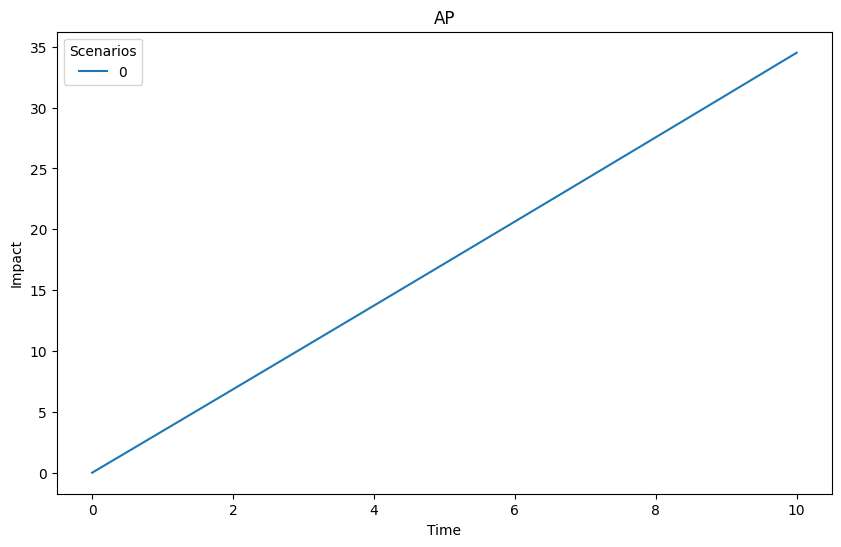

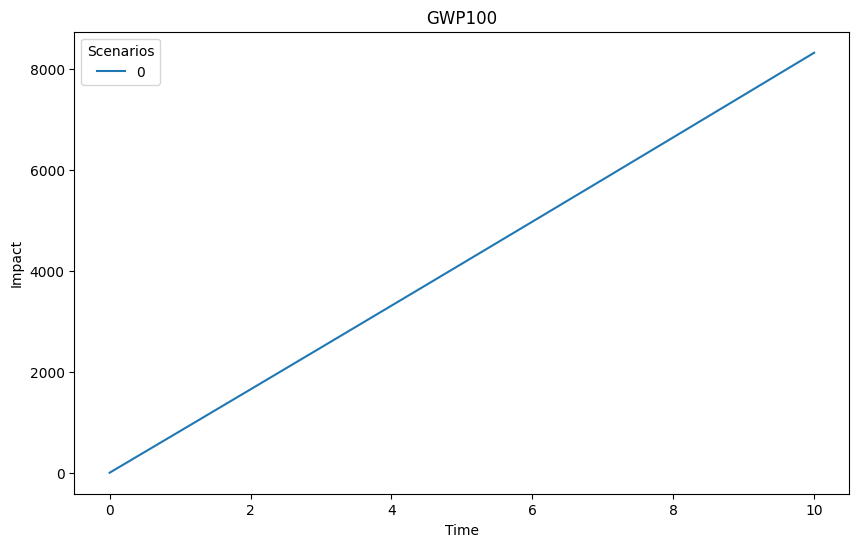

In [111]:
dict_cum_impact_per_category_new_main_process = visualize_dict_lineplots(dataframes_cum_impact_new_main_process, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['0'])

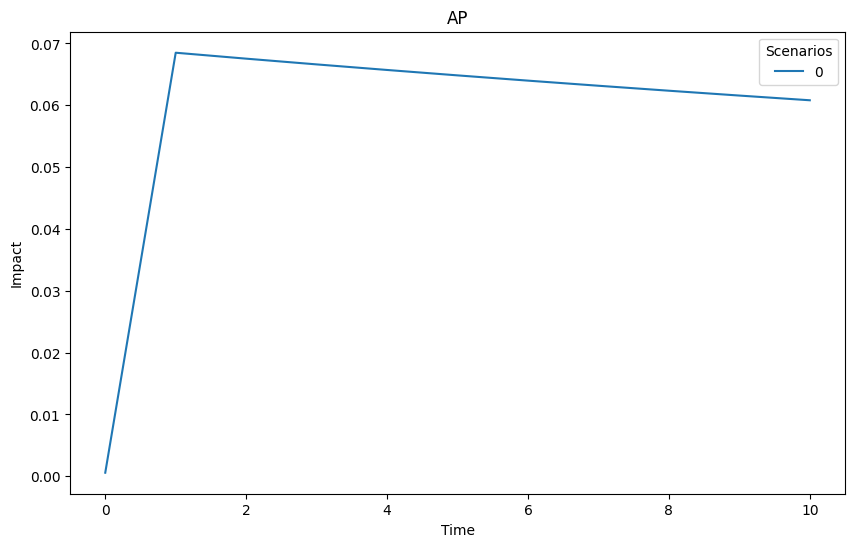

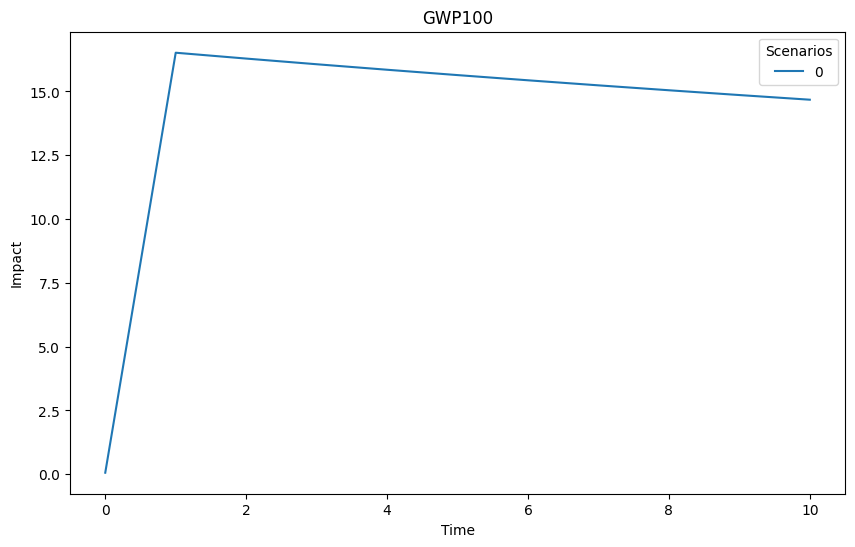

In [112]:
dict_cum_impact_per_fu_per_category_new_main_process = visualize_dict_lineplots(dataframes_cum_impact_per_fu_new_main_process, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['0'])

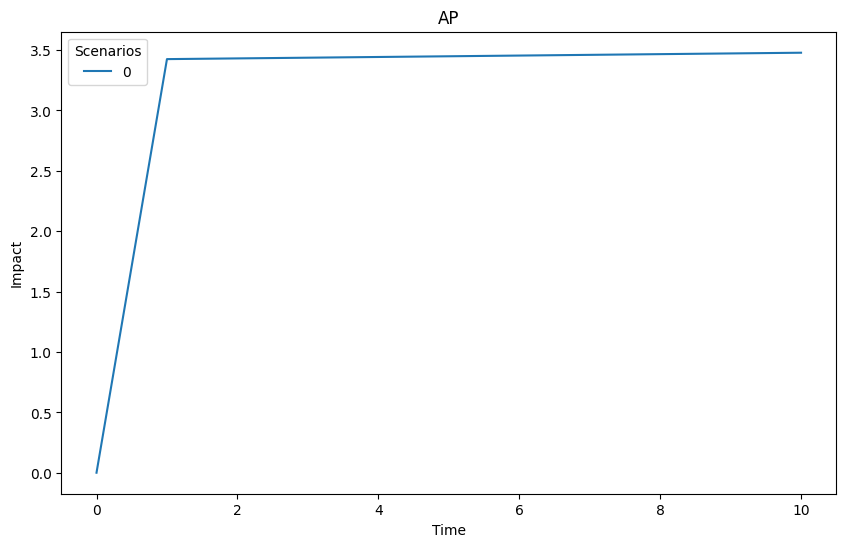

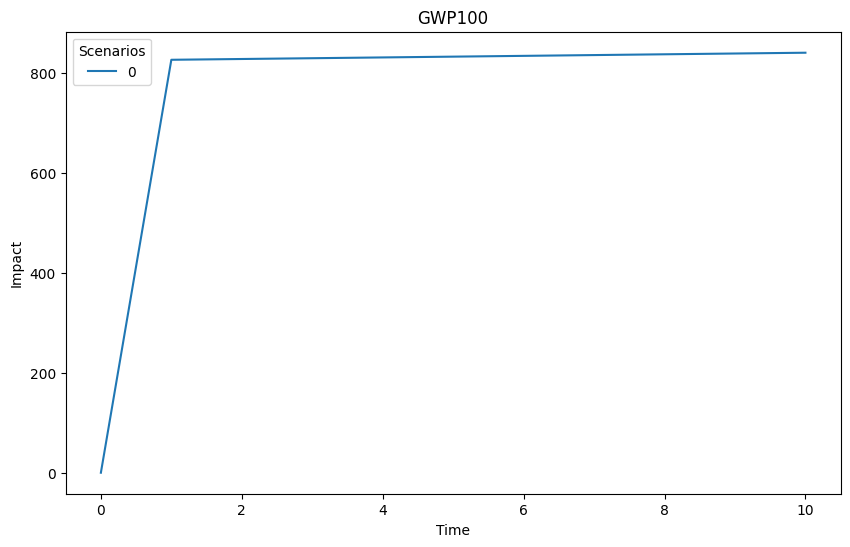

In [113]:
dict_impact_per_category_new_main_process = visualize_dict_lineplots(dataframes_total_impact_new_main_process, impact_categories_names, target_dir, keys_to_plot = ['AP', 'GWP100'], scenarios_to_plot = ['0'])

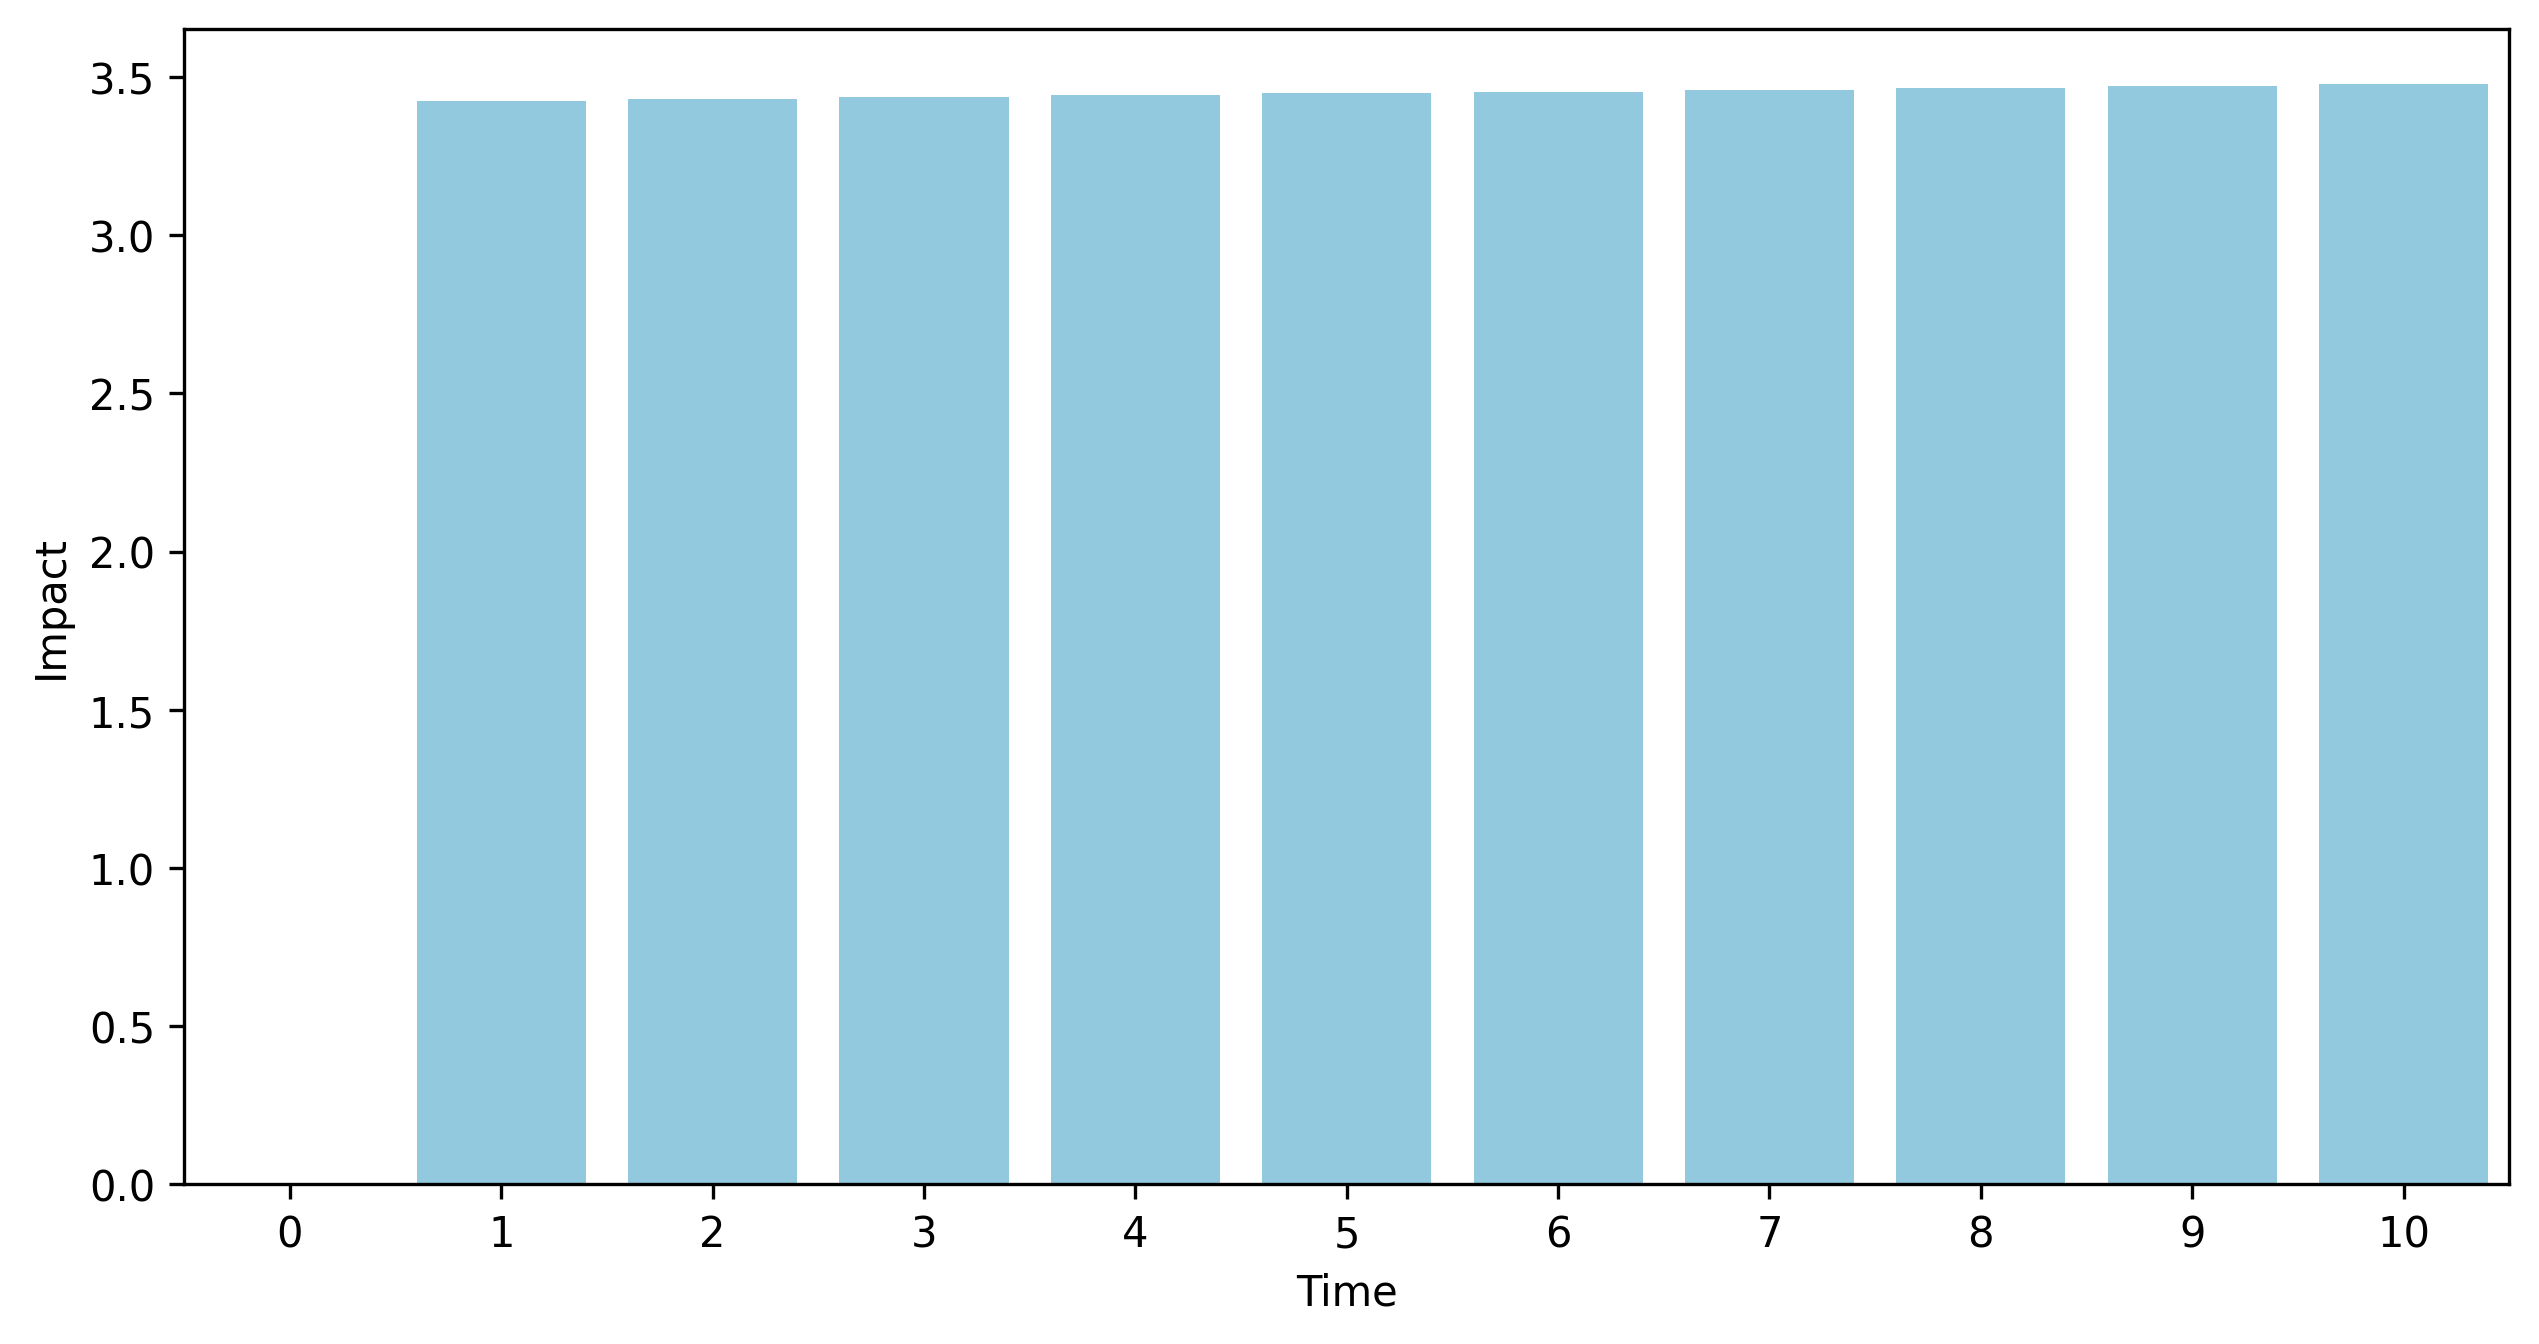

Plot saved: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\0_barplot_AP__.png


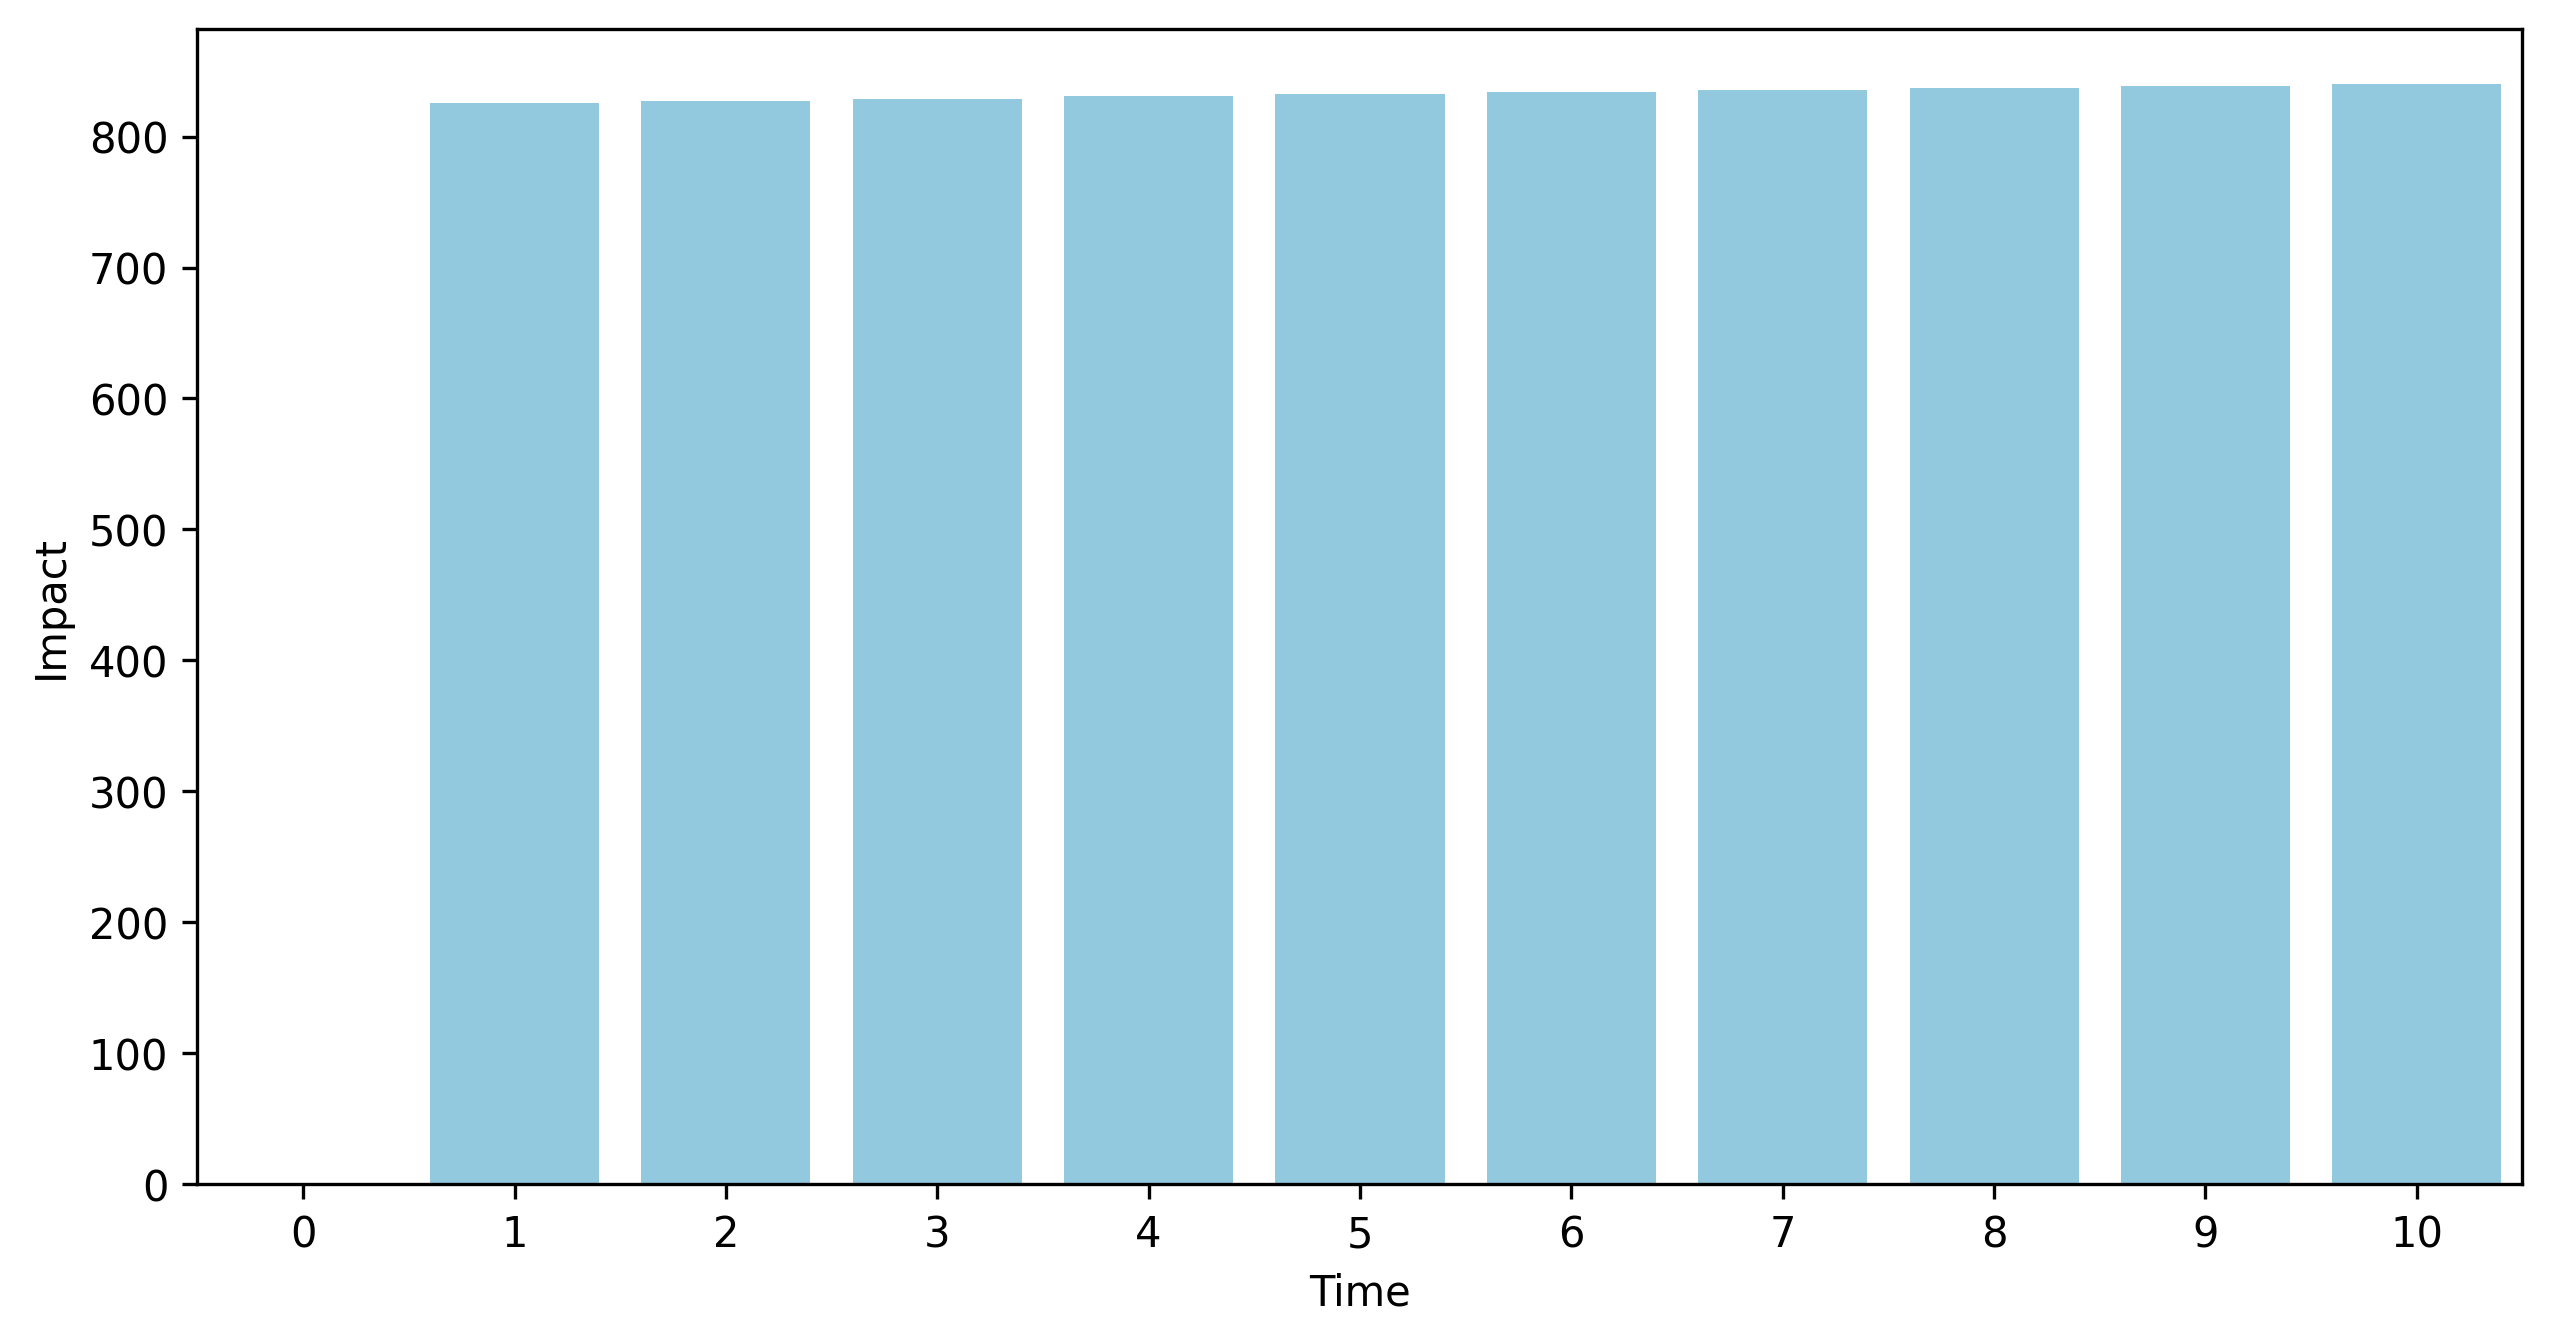

Plot saved: C:\Users\sgkousis\Desktop\Example_results\Results_semi_dynamic\0_barplot_GWP100__.png


In [114]:
plot_bar_charts_by_category(scenario_dict_total_impact_new_main_process, scenarios_to_plot= ['0'],impacts_to_plot = ['AP', 'GWP100'], target_dir = target_dir)

In [115]:
visualize_stacked_barchart_time_series_impact(my_calculator_new_main_process.total_impact_contributions['New main process'], 0,  impact_categories_names, mapping_new_main_process, target_dir, name = "new_main_process")